# Minimal Quantized microGPT Inference (OkLCH Palettes)

This notebook loads **quantized Float16** weights from `web_palette_demo/model_weights.f16.bin`,
runs a minimal autoregressive inference loop, enforces token grammar (`L -> C -> H -> SEP`),
and displays generated palettes.

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Model/tokenizer config (must match training/export).
CFG = {
    "NUM_BINS_L": 42,
    "NUM_BINS_C": 42,
    "NUM_BINS_H": 42,
    "L_BASE": 0,
    "C_BASE": 42,
    "H_BASE": 84,
    "BOS_TOKEN": 126,
    "SEP_TOKEN": 127,
    "VOCAB_SIZE": 128,
    "BLOCK_SIZE": 16,
    "N_LAYER": 1,
    "N_EMBD": 16,
    "N_HEAD": 4,
    "HEAD_DIM": 4,
    "C_MAX": 0.21791855751774927,
}
MLP_HIDDEN = CFG["N_EMBD"] * 4

WEIGHTS_PATH = Path("../weights/model_weights.f16.bin")
if not WEIGHTS_PATH.exists():
    raise FileNotFoundError(f"Missing quantized weights file: {WEIGHTS_PATH.resolve()}")

np.random.seed(42)

In [3]:
def _take_matrix(flat, state, rows, cols):
    n = rows * cols
    start = state["offset"]
    end = start + n
    if end > flat.size:
        raise ValueError("Weights file ended early while decoding matrix")
    mat = flat[start:end].reshape(rows, cols)
    state["offset"] = end
    return mat


def load_runtime_from_f16_bin(path, cfg):
    flat_f16 = np.fromfile(path, dtype=np.float16)
    flat = flat_f16.astype(np.float32, copy=False)

    state = {"offset": 0}
    rt = {"cfg": cfg.copy()}

    rt["wte"] = _take_matrix(flat, state, cfg["VOCAB_SIZE"], cfg["N_EMBD"])
    rt["wpe"] = _take_matrix(flat, state, cfg["BLOCK_SIZE"], cfg["N_EMBD"])
    rt["lm_head"] = _take_matrix(flat, state, cfg["VOCAB_SIZE"], cfg["N_EMBD"])

    layers = []
    for _ in range(cfg["N_LAYER"]):
        layers.append({
            "attn_wq": _take_matrix(flat, state, cfg["N_EMBD"], cfg["N_EMBD"]),
            "attn_wk": _take_matrix(flat, state, cfg["N_EMBD"], cfg["N_EMBD"]),
            "attn_wv": _take_matrix(flat, state, cfg["N_EMBD"], cfg["N_EMBD"]),
            "attn_wo": _take_matrix(flat, state, cfg["N_EMBD"], cfg["N_EMBD"]),
            "mlp_fc1": _take_matrix(flat, state, MLP_HIDDEN, cfg["N_EMBD"]),
            "mlp_fc2": _take_matrix(flat, state, cfg["N_EMBD"], MLP_HIDDEN),
        })
    rt["layers"] = layers

    if state["offset"] != flat.size:
        raise ValueError(f"Weight length mismatch: consumed {state['offset']}, got {flat.size}")

    return rt


runtime = load_runtime_from_f16_bin(WEIGHTS_PATH, CFG)
print(f"Loaded quantized runtime from {WEIGHTS_PATH} ({WEIGHTS_PATH.stat().st_size / 1024:.1f} KB)")

Loaded quantized runtime from ../weights/model_weights.f16.bin (14.5 KB)


In [4]:
def rmsnorm(x, eps=1e-5):
    return x * (np.mean(x * x) + eps) ** -0.5


def softmax(x):
    z = x - np.max(x)
    e = np.exp(z)
    return e / np.sum(e)


def init_cache(rt):
    cfg = rt["cfg"]
    cache = []
    for _ in range(cfg["N_LAYER"]):
        cache.append({
            "k": np.zeros((cfg["BLOCK_SIZE"], cfg["N_EMBD"]), dtype=np.float32),
            "v": np.zeros((cfg["BLOCK_SIZE"], cfg["N_EMBD"]), dtype=np.float32),
            "t": 0,
        })
    return cache


def gpt_step_fast(rt, token_id, pos_id, cache):
    cfg = rt["cfg"]
    x = rt["wte"][token_id] + rt["wpe"][pos_id]
    x = rmsnorm(x)

    for li in range(cfg["N_LAYER"]):
        layer = rt["layers"][li]

        x_res = x
        x = rmsnorm(x)

        q = layer["attn_wq"] @ x
        k = layer["attn_wk"] @ x
        v = layer["attn_wv"] @ x

        c = cache[li]
        t = c["t"]
        c["k"][t] = k
        c["v"][t] = v
        c["t"] = t + 1

        x_attn_parts = []
        for h in range(cfg["N_HEAD"]):
            hs = h * cfg["HEAD_DIM"]
            he = hs + cfg["HEAD_DIM"]

            q_h = q[hs:he]
            k_h = c["k"][: t + 1, hs:he]
            v_h = c["v"][: t + 1, hs:he]

            logits = (k_h @ q_h) / np.sqrt(cfg["HEAD_DIM"])
            w = softmax(logits)
            out_h = w @ v_h
            x_attn_parts.append(out_h)

        x_attn = np.concatenate(x_attn_parts, axis=0)
        x = layer["attn_wo"] @ x_attn
        x = x + x_res

        x_res = x
        x = rmsnorm(x)
        x = layer["mlp_fc1"] @ x
        x = np.maximum(x, 0.0)
        x = layer["mlp_fc2"] @ x
        x = x + x_res

    return rt["lm_head"] @ x


def expected_token_type(cfg, position):
    # Sequence: [BOS, L, C, H, SEP, L, C, H, SEP, L, C, H, SEP, L, C, H, BOS]
    if position <= 0 or position == cfg["BLOCK_SIZE"]:
        return "BOS"
    in_palette = position - 1
    slot = in_palette % 4
    if slot == 0:
        return "L"
    if slot == 1:
        return "C"
    if slot == 2:
        return "H"
    return "SEP"


def token_allowed_at_position(cfg, token_id, position):
    tt = expected_token_type(cfg, position)
    if tt == "L":
        return cfg["L_BASE"] <= token_id < cfg["C_BASE"]
    if tt == "C":
        return cfg["C_BASE"] <= token_id < cfg["H_BASE"]
    if tt == "H":
        return cfg["H_BASE"] <= token_id < cfg["BOS_TOKEN"]
    if tt == "SEP":
        return token_id == cfg["SEP_TOKEN"]
    return token_id == cfg["BOS_TOKEN"]


def assert_prefix_valid(cfg, seq):
    for pos, token_id in enumerate(seq):
        if not token_allowed_at_position(cfg, token_id, pos):
            raise ValueError(f"Invalid prefix token {token_id} at position {pos}")


def sample_constrained(rt, logits, temperature, next_position):
    cfg = rt["cfg"]
    allowed = [tid for tid in range(cfg["VOCAB_SIZE"]) if token_allowed_at_position(cfg, tid, next_position)]

    if len(allowed) == 0:
        raise RuntimeError(f"No allowed tokens at position {next_position}")
    if len(allowed) == 1:
        return allowed[0]

    probs = softmax(logits[allowed] / max(temperature, 1e-6))
    idx = int(np.random.choice(len(allowed), p=probs))
    return allowed[idx]

In [5]:
def dequantize_from_bins(i, lo, hi, bins):
    return lo + (i / (bins - 1)) * (hi - lo)


def decode_palette_tokens(rt, tokens):
    cfg = rt["cfg"]
    l_vals, c_vals, h_vals = [], [], []

    for t in tokens:
        if cfg["L_BASE"] <= t < cfg["C_BASE"]:
            l_vals.append(t - cfg["L_BASE"])
        elif cfg["C_BASE"] <= t < cfg["H_BASE"]:
            c_vals.append(t - cfg["C_BASE"])
        elif cfg["H_BASE"] <= t < cfg["BOS_TOKEN"]:
            h_vals.append(t - cfg["H_BASE"])

    n = min(len(l_vals), len(c_vals), len(h_vals), 4)
    if n == 0:
        return None

    out = []
    for i in range(n):
        out.append([
            dequantize_from_bins(l_vals[i], 0.0, 1.0, cfg["NUM_BINS_L"]),
            dequantize_from_bins(c_vals[i], 0.0, cfg["C_MAX"], cfg["NUM_BINS_C"]),
            dequantize_from_bins(h_vals[i], 0.0, 1.0, cfg["NUM_BINS_H"]),
        ])
    return np.array(out, dtype=np.float32)


def oklch_to_srgb01(oklch):
    L, C, h = float(oklch[0]), float(oklch[1]), float(oklch[2])
    h_rad = h * 2.0 * np.pi

    a = C * np.cos(h_rad)
    b = C * np.sin(h_rad)

    l_ = L + 0.3963377774 * a + 0.2158037573 * b
    m_ = L - 0.1055613458 * a - 0.0638541728 * b
    s_ = L - 0.0894841775 * a - 1.2914855480 * b

    l = l_ ** 3
    m = m_ ** 3
    s = s_ ** 3

    r_lin = 4.0767416621 * l - 3.3077115913 * m + 0.2309699292 * s
    g_lin = -1.2684380046 * l + 2.6097574011 * m - 0.3413193965 * s
    b_lin = -0.0041960863 * l - 0.7034186147 * m + 1.7076147010 * s

    r_lin = np.clip(r_lin, 0.0, 1.0)
    g_lin = np.clip(g_lin, 0.0, 1.0)
    b_lin = np.clip(b_lin, 0.0, 1.0)

    def encode(u):
        return 12.92 * u if u <= 0.0031308 else 1.055 * (u ** (1 / 2.4)) - 0.055

    return np.array([encode(r_lin), encode(g_lin), encode(b_lin)], dtype=np.float32)


def palette_to_rgb01(palette_oklch):
    return np.stack([oklch_to_srgb01(c) for c in palette_oklch], axis=0)


def srgb_byte_to_linear(v):
    x = v / 255.0
    return x / 12.92 if x <= 0.04045 else ((x + 0.055) / 1.055) ** 2.4


def rgb_bytes_to_oklch(r, g, b, c_max):
    rr = srgb_byte_to_linear(r)
    gg = srgb_byte_to_linear(g)
    bb = srgb_byte_to_linear(b)

    l = 0.4122214708 * rr + 0.5363325363 * gg + 0.0514459929 * bb
    m = 0.2119034982 * rr + 0.6806995451 * gg + 0.1073969566 * bb
    s = 0.0883024619 * rr + 0.2817188376 * gg + 0.6299787005 * bb

    l3 = np.cbrt(l)
    m3 = np.cbrt(m)
    s3 = np.cbrt(s)

    L = 0.2104542553 * l3 + 0.7936177850 * m3 - 0.0040720468 * s3
    a = 1.9779984951 * l3 - 2.4285922050 * m3 + 0.4505937099 * s3
    b2 = 0.0259040371 * l3 + 0.7827717662 * m3 - 0.8086757660 * s3

    h = np.arctan2(b2, a) / (2.0 * np.pi)
    if h < 0:
        h += 1.0

    C = np.sqrt(a * a + b2 * b2)
    return np.array([np.clip(L, 0.0, 1.0), np.clip(C, 0.0, c_max), h], dtype=np.float32)


def oklch_to_tokens(rt, color):
    cfg = rt["cfg"]
    l_bin = int(np.clip(np.round(np.clip(color[0], 0.0, 1.0) * (cfg["NUM_BINS_L"] - 1)), 0, cfg["NUM_BINS_L"] - 1))
    c_scaled = np.clip(color[1], 0.0, cfg["C_MAX"]) / max(cfg["C_MAX"], 1e-8)
    c_bin = int(np.clip(np.round(c_scaled * (cfg["NUM_BINS_C"] - 1)), 0, cfg["NUM_BINS_C"] - 1))
    h_bin = int(np.clip(np.round(np.clip(color[2], 0.0, 1.0) * (cfg["NUM_BINS_H"] - 1)), 0, cfg["NUM_BINS_H"] - 1))
    return [cfg["L_BASE"] + l_bin, cfg["C_BASE"] + c_bin, cfg["H_BASE"] + h_bin]


def normalize_forced_color(color, c_max):
    if color is None:
        return None
    c = np.asarray(color, dtype=np.float32)
    return np.array([np.clip(c[0], 0.0, 1.0), np.clip(c[1], 0.0, c_max), c[2] % 1.0], dtype=np.float32)


def show_palettes(palettes_rgb01, title="Generated palettes", n_cols=6):
    if len(palettes_rgb01) == 0:
        print("No palettes to display")
        return

    n_palettes = len(palettes_rgb01)
    n_rows = (n_palettes + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.0, n_rows * 0.7), squeeze=False)
    axes = axes.flatten()

    for i, palette in enumerate(palettes_rgb01):
        cmap = mcolors.ListedColormap(palette.tolist())
        axes[i].imshow([list(range(len(palette)))], cmap=cmap, aspect="auto")
        axes[i].set_xticks([])
        axes[i].set_yticks([])

    for j in range(n_palettes, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [6]:
TEMPERATURE_PRESETS = {
    "low": {"first": 0.30, "middle": 0.20, "last": 0.10},
    "medium": {"first": 0.85, "middle": 0.77, "last": 0.766},
    "high": {"first": 1.00, "middle": 0.92, "last": 0.90},
}

MODE_RULES = {
    "normal": {"max_attempts": 300, "min_vibrant": 0},
    "vibrant": {"max_attempts": 900, "min_vibrant": 2},
    "veryVibrant": {"max_attempts": 1200, "min_vibrant": 3},
    "pastel": {"max_attempts": 1200, "min_vibrant": 0, "pastel": True},
    "grey": {"max_attempts": 700, "min_vibrant": 0, "grey": True},
    "computer90s": {"max_attempts": 700, "min_vibrant": 0, "computer90s": True},
    "extremeComputer90s": {"max_attempts": 700, "min_vibrant": 0, "extremeComputer90s": True},
}

WEBSAFE_STEPS = np.array([0, 51, 102, 153, 204, 255], dtype=np.int32)


def temperature_from_progress(rt, seq, t_first, t_middle, t_last):
    sep = rt["cfg"]["SEP_TOKEN"]
    completed = int(np.sum(np.array(seq) == sep))
    if completed == 0:
        return t_first
    if completed >= 3:
        return t_last
    return t_middle


def count_vibrant_colors(palette_oklch, c_max):
    c_thresh = min(0.12, 0.95 * c_max)
    n = 0
    for c in palette_oklch:
        if c[1] >= c_thresh and 0.35 <= c[0] <= 0.82:
            n += 1
    return n


def is_pastel_palette(palette_oklch, c_max):
    c_soft_max = min(0.10, 0.70 * c_max)
    soft = 0
    dark_anchor = 0
    for c in palette_oklch:
        if c[1] > c_soft_max:
            return False
        if 0.62 <= c[0] <= 0.95:
            soft += 1
        elif 0.18 <= c[0] <= 0.50:
            dark_anchor += 1
        else:
            return False
    return soft >= 3 and dark_anchor >= 1


def is_grey_palette(palette_oklch, c_max):
    low_chroma = min(0.075, 0.36 * c_max)
    very_low = min(0.05, 0.26 * c_max)
    near_neutral = 0
    for c in palette_oklch:
        if c[1] > low_chroma:
            return False
        if c[1] <= very_low:
            near_neutral += 1
    return near_neutral >= 3


def random_oklch_color_for_mode(mode, c_max):
    if mode == "grey":
        l = np.random.uniform(0.34, 0.84)
        c = np.random.uniform(0.0, min(0.018, 0.12 * c_max))
        return np.array([l, c, np.random.rand()], dtype=np.float32)

    if mode == "pastel":
        l = np.random.uniform(0.66, 0.90)
        c = np.random.uniform(0.02, min(0.065, 0.55 * c_max))
        return np.array([l, c, np.random.rand()], dtype=np.float32)

    if mode in ("computer90s", "extremeComputer90s"):
        r = int(np.random.choice(WEBSAFE_STEPS))
        g = int(np.random.choice(WEBSAFE_STEPS))
        b = int(np.random.choice(WEBSAFE_STEPS))
        return rgb_bytes_to_oklch(r, g, b, c_max)

    l = np.random.uniform(0.50, 0.82)
    c_low = min(max(0.08, 0.55 * c_max), c_max)
    c_high = c_max
    if c_low >= c_high:
        c_low = 0.5 * c_high
    c = np.random.uniform(c_low, c_high)
    return np.array([l, c, np.random.rand()], dtype=np.float32)


def sample_from_prefix_dynamic(rt, prefix, t_first, t_middle, t_last):
    cfg = rt["cfg"]
    seq = list(prefix)
    assert_prefix_valid(cfg, seq)

    cache = init_cache(rt)
    logits = None

    for pos, token_id in enumerate(seq):
        if pos >= cfg["BLOCK_SIZE"]:
            return seq
        logits = gpt_step_fast(rt, token_id, pos, cache)

    while len(seq) <= cfg["BLOCK_SIZE"]:
        next_pos = len(seq)
        temp = temperature_from_progress(rt, seq, t_first, t_middle, t_last)
        token_id = sample_constrained(rt, logits, temp, next_pos)
        seq.append(token_id)

        if token_id == cfg["BOS_TOKEN"]:
            break

        pos = len(seq) - 1
        if pos >= cfg["BLOCK_SIZE"]:
            break
        logits = gpt_step_fast(rt, token_id, pos, cache)

    return seq


def generate_palette_with_mode(
    rt,
    mode="normal",
    temperature_profile="medium",
    forced_a=None,
    forced_b=None,
    max_attempts=None,
    return_debug=False,
 ):
    cfg = rt["cfg"]
    rules = MODE_RULES.get(mode, MODE_RULES["normal"])
    temps = TEMPERATURE_PRESETS.get(temperature_profile, TEMPERATURE_PRESETS["medium"])
    forced_a = normalize_forced_color(forced_a, cfg["C_MAX"])
    forced_b = normalize_forced_color(forced_b, cfg["C_MAX"])
    attempts_cap = rules["max_attempts"] if max_attempts is None else int(max_attempts)

    for attempt in range(1, attempts_cap + 1):
        first = forced_a if forced_a is not None else random_oklch_color_for_mode(mode, cfg["C_MAX"])

        second = forced_b
        if second is None and rules.get("extremeComputer90s", False):
            second = random_oklch_color_for_mode("extremeComputer90s", cfg["C_MAX"])

        first_tokens = oklch_to_tokens(rt, first)
        prefix = [cfg["BOS_TOKEN"], first_tokens[0], first_tokens[1], first_tokens[2], cfg["SEP_TOKEN"]]

        if second is not None:
            second_tokens = oklch_to_tokens(rt, second)
            prefix.extend([second_tokens[0], second_tokens[1], second_tokens[2], cfg["SEP_TOKEN"]])

        seq = sample_from_prefix_dynamic(rt, prefix, temps["first"], temps["middle"], temps["last"])
        assert_prefix_valid(cfg, seq)

        payload = [t for t in seq if t not in (cfg["BOS_TOKEN"], cfg["SEP_TOKEN"])]
        palette_oklch = decode_palette_tokens(rt, payload)
        if palette_oklch is None or len(palette_oklch) < 4:
            continue

        palette_oklch = palette_oklch[:4].copy()
        if forced_a is not None:
            palette_oklch[0] = forced_a
        if second is not None:
            palette_oklch[1] = second

        vibrant_count = count_vibrant_colors(palette_oklch, cfg["C_MAX"])
        if vibrant_count < rules["min_vibrant"]:
            continue

        if rules.get("pastel", False) and not is_pastel_palette(palette_oklch, cfg["C_MAX"]):
            continue

        if rules.get("grey", False) and not is_grey_palette(palette_oklch, cfg["C_MAX"]):
            continue

        rgb01 = palette_to_rgb01(palette_oklch)
        if return_debug:
            return rgb01, {"attempt": attempt, "seq": seq, "mode": mode, "temperature": temperature_profile}
        return rgb01

    if return_debug:
        return None, {"attempt": attempts_cap, "seq": None, "mode": mode, "temperature": temperature_profile}
    return None

Accepted 18/18 palettes (normal mode)


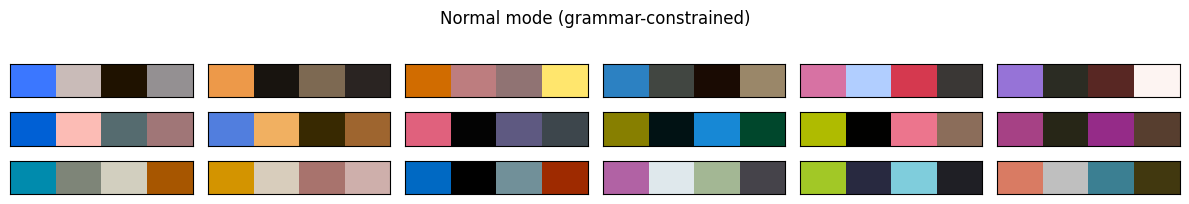

normal: 8/8


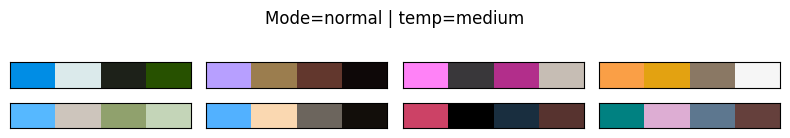

vibrant: 8/8


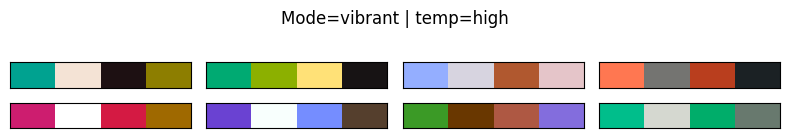

veryVibrant: 8/8


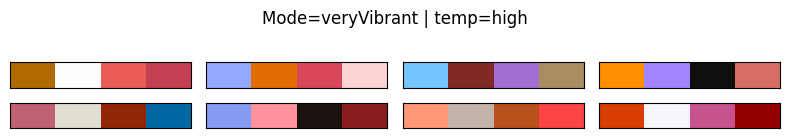

pastel: 7/8


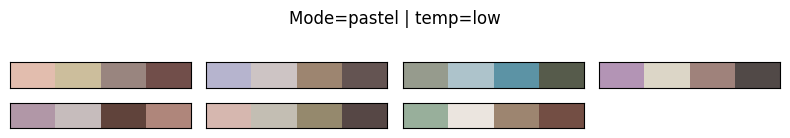

grey: 8/8


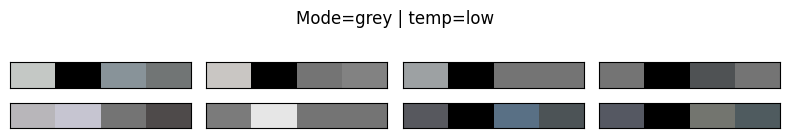

computer90s: 8/8


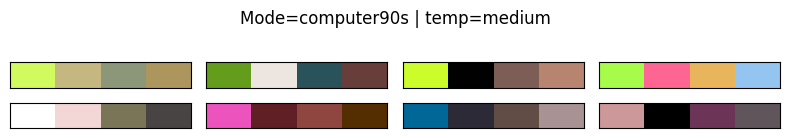

extremeComputer90s: 8/8


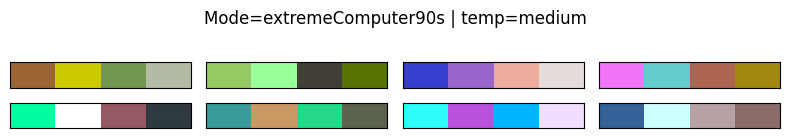

Prefix demo accepted 10/10
Example debug: {'attempt': 3, 'mode': 'vibrant', 'temperature': 'high'}


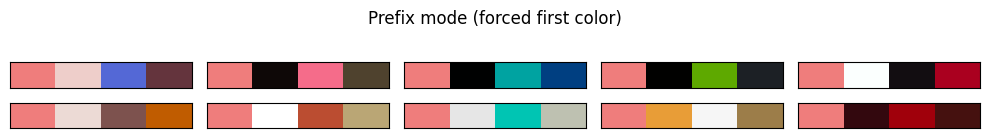

In [7]:
# 1) Baseline batch with cleaner palette rendering
num_samples = 18
rgb_palettes = []
accepted = 0

for _ in range(num_samples):
    rgb01 = generate_palette_with_mode(
        runtime,
        mode="normal",
        temperature_profile="medium",
    )
    if rgb01 is not None:
        rgb_palettes.append(rgb01)
        accepted += 1

print(f"Accepted {accepted}/{num_samples} palettes (normal mode)")
show_palettes(rgb_palettes, title="Normal mode (grammar-constrained)", n_cols=6)


# 2) Multi-mode showcase inspired by paletteWorker10.js
mode_plan = [
    ("normal", "medium"),
    ("vibrant", "high"),
    ("veryVibrant", "high"),
    ("pastel", "low"),
    ("grey", "low"),
    ("computer90s", "medium"),
    ("extremeComputer90s", "medium"),
]

for mode_name, temp_name in mode_plan:
    mode_palettes = []
    for _ in range(8):
        rgb01 = generate_palette_with_mode(
            runtime,
            mode=mode_name,
            temperature_profile=temp_name,
        )
        if rgb01 is not None:
            mode_palettes.append(rgb01)

    print(f"{mode_name}: {len(mode_palettes)}/8")
    show_palettes(mode_palettes, title=f"Mode={mode_name} | temp={temp_name}", n_cols=4)


# 3) Prefix/forced-color demo (forced first color, optional second color)
forced_a = np.array([0.72, 0.14, 0.06], dtype=np.float32)  # warm vivid seed
forced_b = None  # try also: np.array([0.45, 0.12, 0.58], dtype=np.float32)

prefill_palettes = []
prefill_meta = []
for _ in range(10):
    rgb01, meta = generate_palette_with_mode(
        runtime,
        mode="vibrant",
        temperature_profile="high",
        forced_a=forced_a,
        forced_b=forced_b,
        return_debug=True,
    )
    if rgb01 is not None:
        prefill_palettes.append(rgb01)
        prefill_meta.append(meta)

print(f"Prefix demo accepted {len(prefill_palettes)}/10")
if prefill_meta:
    print("Example debug:", {k: v for k, v in prefill_meta[0].items() if k != "seq"})
show_palettes(prefill_palettes, title="Prefix mode (forced first color)", n_cols=5)